<a href="https://colab.research.google.com/github/RAZAMZALAG/Statistics-2/blob/main/ProjectEx1_206922478_XXXXXXXXX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Assignment 1 — Statistics 2 📊
**Course:** Statistics 2 | Spring 2025

**Submitted by:**
- Raz Amzaleg | ID: 206922478
- Ben Hen | ID: [XXXXXXXXX]

---

## Section 1: Data Selection and Preparation

### 1.1 Dataset Description

**Original Dataset:** [Airline Passenger Satisfaction — Kaggle](https://www.kaggle.com/datasets/johndddddd/customer-satisfaction)

This dataset contains survey responses from airline passengers recording their satisfaction with various aspects of their flight experience. Each row represents a single passenger and includes demographic information (age, gender), flight details (class, distance, delay), service ratings across multiple dimensions, and an overall satisfaction label.

The following preparation steps were performed on the raw data:
1. **Binary encoding:** Mapped categorical columns (`Gender`, `Customer Type`, `Type of Travel`, `satisfaction_v2`) to numeric 0/1 values.
2. **Ordinal encoding:** Mapped `Class` to an ordered numeric scale (Eco=0, Eco Plus=1, Business=2).
3. **Handling "Not Applicable" values:** Replaced `0` ratings in all service columns with `NaN` before computing composite scores.
4. **Feature engineering — Composite Scores:** Created three continuous features by averaging related service items:
   - `Inflight_Score`: in-flight service items (leg room, entertainment, seat comfort, food, cleanliness, wifi, on-board service)
   - `Online_Score`: digital experience items (online boarding, ease of booking, online support)
   - `Ground_Score`: ground service items (check-in, gate location, baggage handling)
5. **Column removal:** Dropped `id`, `Arrival Delay in Minutes`, and all original service item columns.
6. **Sampling:** Randomly sampled **10,000 observations** (`random_state=42`) and saved as `satisfaction_reduced.csv`.

In [1]:
# Question 1 — Section 1.1: Data Preparation

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="muted")

def load_and_prepare(filepath: str) -> pd.DataFrame:
    """
    Load the raw airline satisfaction Excel file and apply all preparation steps:
    - Map categorical variables to binary/ordinal numeric values
    - Replace 0 ratings with NaN in service columns
    - Engineer composite score features (Inflight, Online, Ground)
    - Drop irrelevant columns and raw service item columns
    - Sample 10,000 observations randomly

    Parameters
    ----------
    filepath : str
        Path to the raw Excel file (satisfaction.xlsx).

    Returns
    -------
    pd.DataFrame
        Cleaned and transformed dataset ready for analysis.
    """
    df = pd.read_excel(filepath)

    # ── Binary encoding of categorical variables ──────────────────────────────
    df['satisfaction_v2'] = df['satisfaction_v2'].map({'neutral or dissatisfied': 0, 'satisfied': 1})
    df['Gender']          = df['Gender'].map({'Male': 0, 'Female': 1})
    df['Customer Type']   = df['Customer Type'].map({'disloyal Customer': 0, 'Loyal Customer': 1})
    df['Type of Travel']  = df['Type of Travel'].map({'Personal Travel': 0, 'Business travel': 1})

    # ── Ordinal encoding (Class has a natural order) ──────────────────────────
    df['Class'] = df['Class'].map({'Eco': 0, 'Eco Plus': 1, 'Business': 2})

    # ── Replace 0 ratings with NaN (0 = Not Applicable in this survey) ───────
    service_cols = [
        'Leg room service', 'Inflight entertainment', 'Seat comfort',
        'Food and drink', 'Cleanliness', 'Inflight wifi service',
        'On-board service', 'Checkin service', 'Gate location',
        'Baggage handling', 'Ease of Online booking', 'Online support', 'Online boarding'
    ]
    df2 = df[service_cols].replace(0, np.nan)

    # ── Composite scores ──────────────────────────────────────────────────────
    df['Inflight_Score'] = df2[[
        'Leg room service', 'Inflight entertainment', 'Seat comfort',
        'Food and drink', 'Cleanliness', 'Inflight wifi service', 'On-board service'
    ]].mean(axis=1)

    df['Online_Score'] = df2[[
        'Online boarding', 'Ease of Online booking', 'Online support'
    ]].mean(axis=1)

    df['Ground_Score'] = df2[[
        'Checkin service', 'Gate location', 'Baggage handling'
    ]].mean(axis=1)

    # ── Drop irrelevant and raw service columns ───────────────────────────────
    df.drop(columns=['id', 'Arrival Delay in Minutes'], inplace=True)
    df.drop(columns=service_cols, inplace=True)

    # ── Sample 10,000 rows ────────────────────────────────────────────────────
    df = df.sample(n=10_000, random_state=42).reset_index(drop=True)
    df.to_csv('satisfaction_reduced.csv', index=False)
    return df

# ── Load the pre-processed dataset ───────────────────────────────────────────
df = pd.read_csv('satisfaction_reduced.csv')
print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn list:\n{df.columns.tolist()}")


Dataset loaded: 10,000 rows × 12 columns

Column list:
['satisfaction_v2', 'Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Departure/Arrival time convenient', 'Departure Delay in Minutes', 'Inflight_Score', 'Online_Score', 'Ground_Score']


### 1.2 Missing Values Check

In [2]:
# Question 1 — Section 1.2: Missing Values Report

def missing_values_report(df: pd.DataFrame) -> None:
    """
    Print a sorted report of missing values per column.
    Only columns with at least one missing value are shown.

    Parameters
    ----------
    df : pd.DataFrame
        The dataset to inspect.
    """
    nulls = df.isna().sum()
    columns_with_nulls = nulls[nulls > 0].sort_values(ascending=False)

    if columns_with_nulls.empty:
        print("✓ No missing values found across all records.")
    else:
        print("Columns with missing values:")
        print(columns_with_nulls)

missing_values_report(df)


✓ No missing values found across all records.


### 1.3 Final Data Dictionary

The processed dataset (`satisfaction_reduced.csv`) contains **10,000 records** and **12 columns**:

| Column Name | Variable Type | Description |
| :--- | :--- | :--- |
| **Age** | Numeric (Continuous) | Passenger age in years |
| **Flight Distance** | Numeric (Continuous) | Flight distance in miles |
| **Departure Delay in Minutes** | Numeric (Continuous) | Departure delay in minutes |
| **Inflight_Score** | Numeric (Continuous) | Avg. rating (1–5) of in-flight services |
| **Ground_Score** | Numeric (Continuous) | Avg. rating (1–5) of ground services |
| **Online_Score** | Numeric (Continuous) | Avg. rating (1–5) of digital/online experience |
| **Departure/Arrival time convenient** | Ordinal / Numeric | Convenience rating of flight times (1–5) |
| **Class** | Categorical | Travel class: 0 = Eco, 1 = Eco Plus, 2 = Business |
| **Gender** | Binary (0/1) | 1 = Female, 0 = Male |
| **Type of Travel** | Binary (0/1) | 1 = Business travel, 0 = Personal travel |
| **Customer Type** | Binary (0/1) | 1 = Loyal Customer, 0 = Disloyal Customer |
| **satisfaction_v2** | Binary (0/1) | Target: 1 = Satisfied, 0 = Neutral/Dissatisfied |

*The dataset fully meets assignment requirements: ≥2 continuous variables, ≥2 binary variables, ≥4,000 records.*

---
## Section 2: Exploratory Data Analysis (EDA)

We perform a univariate analysis for each variable: key descriptive statistics, missing value checks, and visual distribution inspection for continuous and categorical variables.

### 2.0 Summary Statistics

In [3]:
# Question 2 — Section 2.0: Descriptive Statistics for Numeric Variables

def summarize_numeric(df: pd.DataFrame, cols: list) -> None:
    """
    Display descriptive statistics for a list of numeric columns.

    Parameters
    ----------
    df : pd.DataFrame
        Source dataset.
    cols : list of str
        Numeric column names to summarize.
    """
    display(df[cols].describe().round(2))

numeric_cols = [
    'Age', 'Flight Distance', 'Departure Delay in Minutes',
    'Inflight_Score', 'Online_Score', 'Ground_Score'
]
summarize_numeric(df, numeric_cols)


,Age,Flight Distance,Departure Delay in Minutes,Inflight_Score,Online_Score,Ground_Score
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,39.28,1984.69,15.24,3.34,3.45,3.34
std,15.07,1034.00,38.95,0.72,1.14,0.76
min,7.00,50.00,0.00,1.00,1.00,1.00
25%,27.00,1346.75,0.00,2.86,2.67,3.00
50%,40.00,1920.00,0.00,3.43,3.67,3.33
75%,51.00,2558.00,13.00,3.86,4.33,4.00
max,85.00,6951.00,933.00,5.00,5.00,5.00


**Interpretation:**
- **Composite Scores** (`Inflight_Score`, `Online_Score`, `Ground_Score`): means of 3.34–3.45 with medians near 3.33–3.67, indicating moderate-to-positive passenger experience with approximately normal distributions.
- **Departure Delay**: severely right-skewed — median = 0 min (most flights on time), but max reaches 933 min. High std (38.95) vs mean (15.24) confirms the presence of extreme but rare disruptions.

### 2.1 Distribution of Continuous Variables

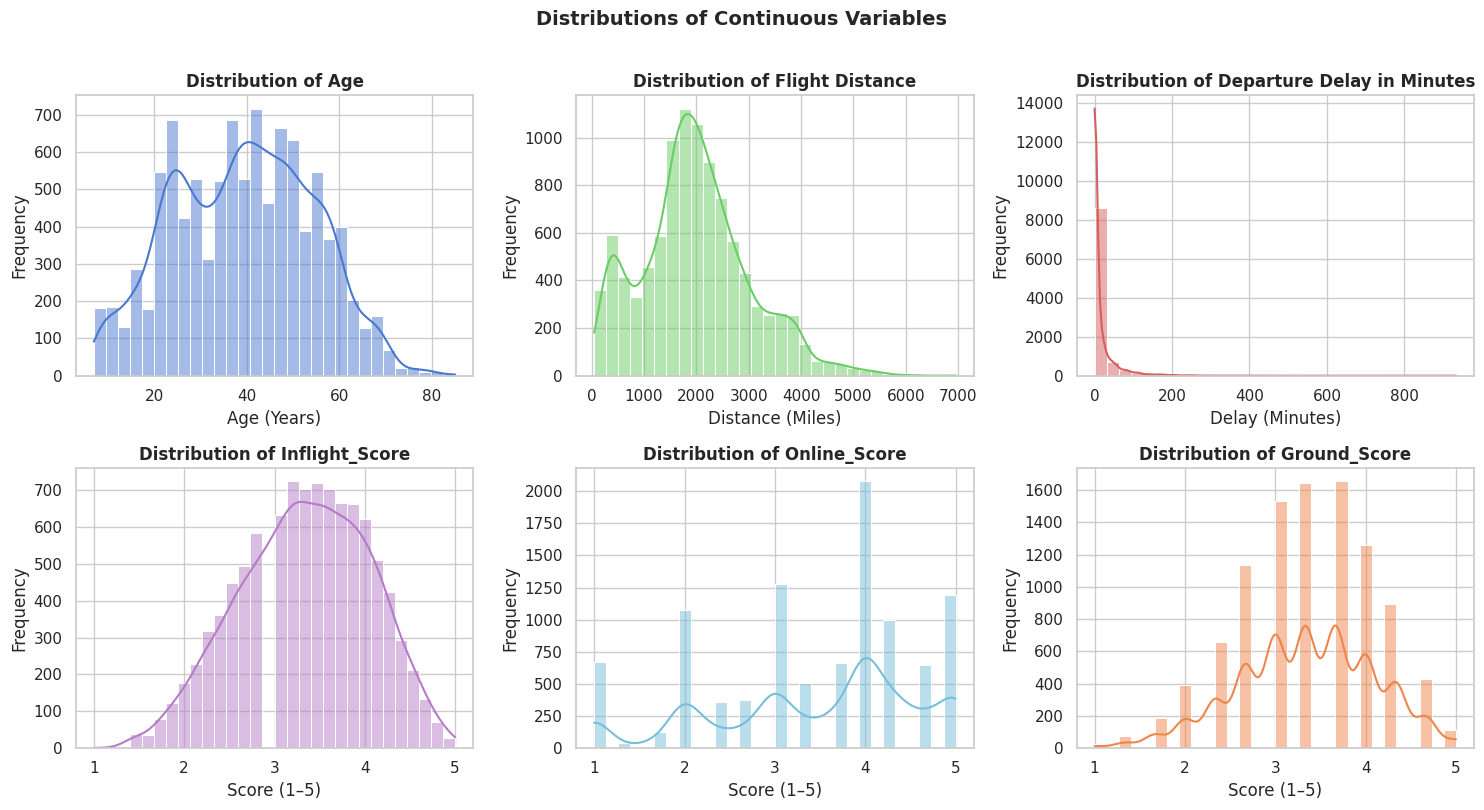

In [4]:
# Question 2 — Section 2.1: Histograms for Continuous Variables

def plot_continuous_distributions(df: pd.DataFrame,
                                   cols: list,
                                   xlabels: list,
                                   colors: list = None) -> None:
    """
    Plot a grid of histograms with KDE curves for continuous variables.

    Parameters
    ----------
    df : pd.DataFrame
        Source dataset.
    cols : list of str
        Column names to plot.
    xlabels : list of str
        X-axis labels corresponding to each column.
    colors : list of str, optional
        Bar colors for each histogram.
    """
    if colors is None:
        colors = ['steelblue'] * len(cols)

    ncols = 3
    nrows = -(-len(cols) // ncols)  # ceiling division
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
    axes = axes.flatten()

    for i, (col, xlabel, color) in enumerate(zip(cols, xlabels, colors)):
        sns.histplot(df[col], bins=30, kde=True, color=color, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel(xlabel)
        axes[i].set_ylabel('Frequency')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Distributions of Continuous Variables', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

continuous_cols   = ['Age', 'Flight Distance', 'Departure Delay in Minutes',
                     'Inflight_Score', 'Online_Score', 'Ground_Score']
continuous_labels = ['Age (Years)', 'Distance (Miles)', 'Delay (Minutes)',
                     'Score (1–5)', 'Score (1–5)', 'Score (1–5)']
continuous_colors = ['#4878cf', '#6acc65', '#d65f5f', '#b47cc7', '#77bedb', '#ee854a']

plot_continuous_distributions(df, continuous_cols, continuous_labels, continuous_colors)


**Interpretation:**
- **Age**: Broad, slightly bimodal distribution (peaks ~40s and ~mid-20s), range 7–85. Predominantly working-age adults, consistent with the dominance of business travelers.
- **Flight Distance**: Right-skewed, concentrated at 1,500–2,500 miles with a long tail of long-haul flights up to ~7,000 miles.
- **Departure Delay**: Severely right-skewed — massive spike at 0 min, very long tail to ~933 min. Most flights depart on time, but rare extreme delays exist.
- **Inflight / Online / Ground Scores**: Near-normal, centered around 3.0–4.0. The slight "staircase" pattern reflects the discrete Likert-scale origin of the raw items.

### 2.2 Outlier Detection

── Departure Delay ──


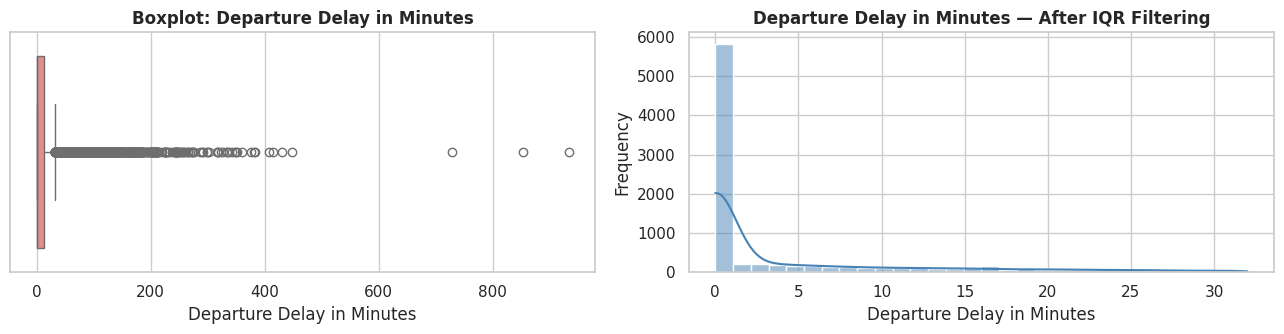

  Q1=0.00 | Q3=13.00 | IQR=13.00
  Bounds: [-19.50, 32.50] | Outliers: 1,358 (13.6%)

── Flight Distance ──


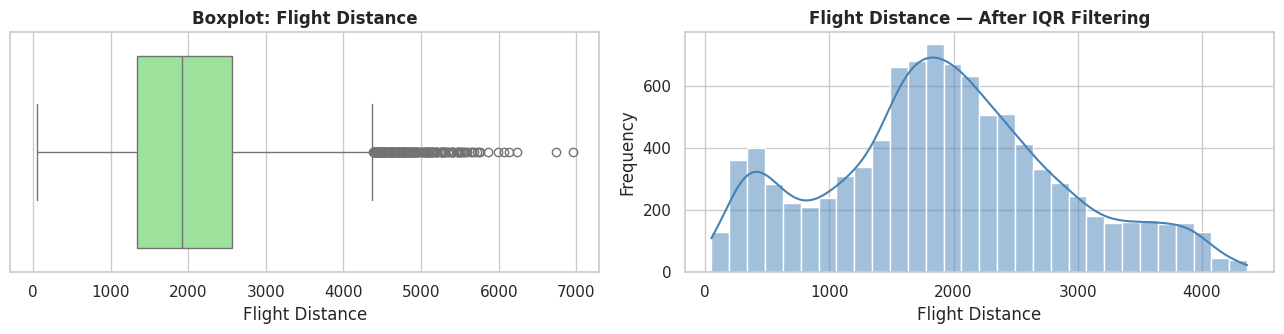

  Q1=1346.75 | Q3=2558.00 | IQR=1211.25
  Bounds: [-470.12, 4374.88] | Outliers: 205 (2.1%)


{'Q1': np.float64(1346.75),
 'Q3': np.float64(2558.0),
 'IQR': np.float64(1211.25),
 'lower_bound': np.float64(-470.125),
 'upper_bound': np.float64(4374.875),
 'outlier_count': 205}

In [5]:
# Question 2 — Section 2.2: Outlier Detection with Boxplots and IQR

def detect_outliers(df: pd.DataFrame, col: str, color: str = 'lightcoral') -> dict:
    """
    Detect outliers in a continuous variable using the IQR method.
    Displays a side-by-side boxplot (full data) and histogram (filtered data).

    Parameters
    ----------
    df : pd.DataFrame
        Source dataset.
    col : str
        Column to analyze.
    color : str
        Boxplot fill color.

    Returns
    -------
    dict
        Keys: Q1, Q3, IQR, lower_bound, upper_bound, outlier_count.
    """
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]

    fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))

    sns.boxplot(x=df[col], color=color, ax=axes[0])
    axes[0].set_title(f'Boxplot: {col}', fontsize=12, fontweight='bold')
    axes[0].set_xlabel(col)

    filtered = df[(df[col] >= lower) & (df[col] <= upper)]
    sns.histplot(filtered[col], bins=30, kde=True, color='steelblue', ax=axes[1])
    axes[1].set_title(f'{col} — After IQR Filtering', fontsize=12, fontweight='bold')
    axes[1].set_xlabel(col)
    axes[1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

    print(f"  Q1={Q1:.2f} | Q3={Q3:.2f} | IQR={IQR:.2f}")
    print(f"  Bounds: [{lower:.2f}, {upper:.2f}] | Outliers: {len(outliers):,} ({len(outliers)/len(df)*100:.1f}%)")
    return dict(Q1=Q1, Q3=Q3, IQR=IQR, lower_bound=lower,
                upper_bound=upper, outlier_count=len(outliers))

print("── Departure Delay ──")
detect_outliers(df, 'Departure Delay in Minutes', color='lightcoral')

print("\n── Flight Distance ──")
detect_outliers(df, 'Flight Distance', color='lightgreen')


**Interpretation:**
- **Departure Delay**: IQR method flags delays > ~32.5 min as outliers (~18% of records). Even after exclusion the distribution remains right-skewed, confirming high punctuality as the norm with rare severe disruptions.
- **Flight Distance**: Outliers (> ~4,375 miles) represent long-haul international flights — physically real data points, not errors. The filtered distribution confirms medium-haul routes (1,500–2,500 miles) as the operational core.

### 2.3 Distribution of Categorical and Binary Variables

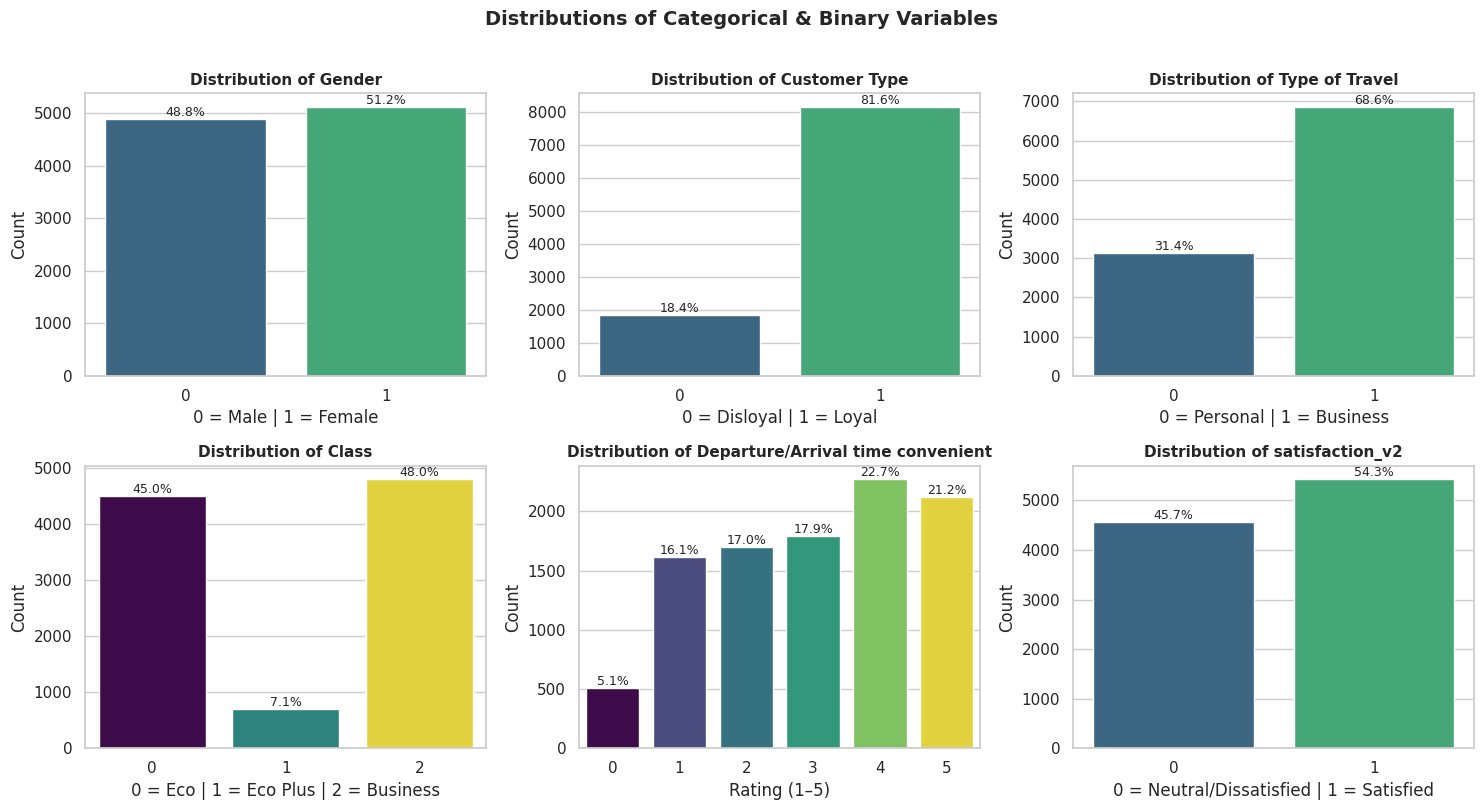

In [6]:
# Question 2 — Section 2.3: Countplots for Categorical and Binary Variables

def plot_categorical_distributions(df: pd.DataFrame, cols_labels: list) -> None:
    """
    Plot a grid of annotated countplots for categorical and binary variables.
    Each bar is annotated with the percentage it represents.

    Parameters
    ----------
    df : pd.DataFrame
        Source dataset.
    cols_labels : list of tuple (str, str)
        Each tuple is (column_name, x_axis_label_with_encoding).
    """
    ncols = 3
    nrows = -(-len(cols_labels) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
    axes = axes.flatten()

    for i, (col, xlabel) in enumerate(cols_labels):
        sns.countplot(data=df, x=col, palette='viridis',
                      hue=col, legend=False, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
        axes[i].set_xlabel(xlabel)
        axes[i].set_ylabel('Count')
        total = len(df)
        for p in axes[i].patches:
            pct = f"{100 * p.get_height() / total:.1f}%"
            axes[i].annotate(pct,
                             (p.get_x() + p.get_width() / 2., p.get_height()),
                             ha='center', va='bottom', fontsize=9)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Distributions of Categorical & Binary Variables',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

cat_cols = [
    ('Gender',                          '0 = Male | 1 = Female'),
    ('Customer Type',                   '0 = Disloyal | 1 = Loyal'),
    ('Type of Travel',                  '0 = Personal | 1 = Business'),
    ('Class',                           '0 = Eco | 1 = Eco Plus | 2 = Business'),
    ('Departure/Arrival time convenient','Rating (1–5)'),
    ('satisfaction_v2',                 '0 = Neutral/Dissatisfied | 1 = Satisfied'),
]

plot_categorical_distributions(df, cat_cols)


**Interpretation:**
- **Gender**: Nearly perfectly balanced (≈50/50) — ideal for unbiased modeling.
- **Customer Type**: Loyal customers (~82%) dominate — the airline's base is largely returning passengers.
- **Type of Travel**: Business travelers (~69%) form the majority, shaping satisfaction drivers.
- **Class**: Eco (~45%) and Business (~48%) dominate; Eco Plus (~7%) is a niche tier.
- **Departure/Arrival time convenient**: Ratings spread broadly across 1–5 with no dominant value — highly subjective perception.
- **satisfaction_v2**: Reasonably balanced (~55% satisfied vs ~45% not) — a good target variable for modeling.

## Section 3: Research Questions

Based on our dataset of **10,000 airline passengers**, we formulate research questions for each required type.

**Dataset variables reminder:**
- **Continuous:** `Age`, `Flight Distance`, `Departure Delay in Minutes`, `Inflight_Score`, `Online_Score`, `Ground_Score`
- **Binary:** `Gender` (0=Male, 1=Female), `Type of Travel` (0=Personal, 1=Business), `Customer Type` (0=Disloyal, 1=Loyal), `satisfaction_v2` (0=Neutral/Dissatisfied, 1=Satisfied)
- **Categorical/Ordinal:** `Class` (0=Eco, 1=Eco Plus, 2=Business), `Departure/Arrival time convenient` (1–5)

---

### 3a. Continuous Predictor → Continuous Outcome (Linear Regression)

**Requirement:** Formulate a regression question where both the explanatory variable (X) and the response variable (Y) are continuous.

---

**Option 1 — Flight Distance & Inflight Score** *(Selected)*

> *Does a passenger's in-flight service score (`Inflight_Score`) predict their flight distance (`Flight Distance`)?*

- **X (Explanatory):** `Inflight_Score` — continuous, range 1–5. Represents the average rating a passenger gave to in-flight services (food, seat comfort, entertainment, wifi, etc.)
- **Y (Response):** `Flight Distance` — continuous, in miles. Represents the total distance of the passenger's flight.
- **Rationale:** Passengers on longer flights may experience higher service quality due to wider aircraft, more attentive crew, and better amenities — potentially leading to higher in-flight ratings. We want to test whether there is a statistically significant linear relationship.

---

**Option 2 — Age & Inflight Score**

> *Does a passenger's age (`Age`) predict their in-flight service score (`Inflight_Score`)?*

- **X (Explanatory):** `Age` — continuous, in years (range 7–85).
- **Y (Response):** `Inflight_Score` — continuous, average service rating (1–5).
- **Rationale:** Older passengers may have higher or lower service expectations, leading to systematically different satisfaction scores. This tests whether age is a linear predictor of perceived in-flight quality.

---

**Option 3 — Departure Delay & Online Score**

> *Does a longer departure delay (`Departure Delay in Minutes`) predict a lower online service score (`Online_Score`)?*

- **X (Explanatory):** `Departure Delay in Minutes` — continuous, in minutes.
- **Y (Response):** `Online_Score` — continuous, average rating of digital services (1–5).
- **Rationale:** A frustrating pre-flight experience (long delay) could bias passengers toward giving lower ratings across all service dimensions, including online services. This tests a potential spillover effect.

### 3b. Continuous Predictor → Binary Outcome (Logistic Regression)

**Requirement:** Formulate a regression question where the explanatory variable (X) is continuous and the response variable (Y) is binary.

---

**Option 1 — Inflight Score & Satisfaction** *(Selected)*

> *Does a higher in-flight service score (`Inflight_Score`) increase the probability that a passenger reports overall satisfaction (`satisfaction_v2 = 1`)?*

- **X (Explanatory):** `Inflight_Score` — continuous, average in-flight service rating (1–5).
- **Y (Response):** `satisfaction_v2` — binary: 1 = Satisfied, 0 = Neutral or Dissatisfied.
- **Rationale:** The in-flight experience is arguably the core product of an airline. It is reasonable to hypothesise that passengers who rate it higher are significantly more likely to be overall satisfied. This is a classic logistic regression setup.

---

**Option 2 — Flight Distance & Loyal Customer**

> *Does flying a longer distance (`Flight Distance`) increase the probability that a passenger is a loyal customer (`Customer Type = 1`)?*

- **X (Explanatory):** `Flight Distance` — continuous, in miles.
- **Y (Response):** `Customer Type` — binary: 1 = Loyal Customer, 0 = Disloyal.
- **Rationale:** Frequent long-distance travelers may be more likely to be loyal (e.g., business flyers with corporate contracts). This tests whether distance flown is a predictor of customer loyalty.

---

**Option 3 — Departure Delay & Satisfaction**

> *Does a longer departure delay (`Departure Delay in Minutes`) decrease the probability that a passenger is satisfied (`satisfaction_v2 = 1`)?*

- **X (Explanatory):** `Departure Delay in Minutes` — continuous, in minutes.
- **Y (Response):** `satisfaction_v2` — binary: 1 = Satisfied, 0 = Neutral or Dissatisfied.
- **Rationale:** Delays are one of the most direct sources of passenger frustration. This question tests whether the length of a delay has a measurable negative effect on the probability of overall satisfaction.

### 3c. Hypothesis Test — Continuous Variable vs Binary Group

**Requirement:** Formulate a hypothesis test question asking whether the value of a continuous variable (X) differs significantly between the two categories of a binary variable (Y).

---

**Option 1 — Flight Distance & Type of Travel** *(Selected)*

> *Is the average flight distance (`Flight Distance`) significantly different between business travelers and personal travelers (`Type of Travel`)?*

- **Continuous variable (X):** `Flight Distance` — in miles.
- **Binary group variable (Y):** `Type of Travel` — 0 = Personal Travel, 1 = Business Travel.
- **Rationale:** Business travelers are expected to fly longer distances on average, since corporate destinations tend to be more geographically dispersed. This is a classic two-sample test of means.
- **Expected method:** Independent samples t-test, or Mann-Whitney U test if normality is violated.

---

**Option 2 — Inflight Score & Satisfaction**

> *Is the average in-flight service score (`Inflight_Score`) significantly different between satisfied and dissatisfied passengers (`satisfaction_v2`)?*

- **Continuous variable (X):** `Inflight_Score` — average in-flight rating (1–5).
- **Binary group variable (Y):** `satisfaction_v2` — 0 = Neutral/Dissatisfied, 1 = Satisfied.
- **Rationale:** If in-flight service is a key driver of satisfaction, we would expect satisfied passengers to have significantly higher `Inflight_Score` values. This directly tests that hypothesis.
- **Expected method:** Independent samples t-test.

---

**Option 3 — Age & Customer Loyalty**

> *Is the average age (`Age`) significantly different between loyal and disloyal customers (`Customer Type`)?*

- **Continuous variable (X):** `Age` — in years.
- **Binary group variable (Y):** `Customer Type` — 0 = Disloyal Customer, 1 = Loyal Customer.
- **Rationale:** Older passengers may have longer travel histories and therefore be more likely to be loyal customers. This tests whether age differs meaningfully between loyalty groups.
- **Expected method:** Independent samples t-test, or Mann-Whitney U test if normality is violated.